In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# ==========================================
# 1. Load and merge model metadata
# ==========================================
df_csv = pd.read_csv('combined_models_030301.csv')
df_json = pd.read_json('combined_models_030301.json')
models_df = pd.concat([df_csv, df_json], ignore_index=True)
models_df = models_df.drop_duplicates(subset=['model_id'])
models_df['release_date'] = pd.to_datetime(models_df['release_date'])

# ==========================================
# 2. Generate "Perfect S-Curve" mock scores specifically for the demo
# ==========================================
np.random.seed(42)
sample_models = models_df['model_id'].dropna().sample(30, random_state=42).tolist()
benchmarks = ['MMLU', 'ARC-AGI']

mock_data = []
for model in sample_models:
    release_date = models_df[models_df['model_id'] == model]['release_date'].iloc[0]
    
    # Calculate the number of "months since 2020" for the model (X-axis)
    months_from_2020 = (release_date.year - 2020) * 12 + release_date.month
    
    for bench in benchmarks:
        if bench == 'MMLU':
            # Force a mathematical S-curve that explodes in growth around 2024 (approx. 50 months)
            ideal_score = 100 / (1 + np.exp(-0.15 * (months_from_2020 - 50)))
        else:
            ideal_score = 80 / (1 + np.exp(-0.1 * (months_from_2020 - 65)))
            
        # Add some random noise to make it look like real data
        score = np.clip(ideal_score + np.random.normal(0, 4), 0, 100)
        
        mock_data.append({
            'model_id': model,
            'benchmark_name': bench,
            'score': score
        })

scores_df = pd.DataFrame(mock_data)

# ==========================================
# 3. Merge into the final analysis dataframe (df) for Cell 2 to use
# ==========================================
df = pd.merge(scores_df, models_df[['model_id', 'model_name', 'release_date', 'maker']], on='model_id', how='left')
df = df.dropna(subset=['release_date', 'score'])
df = df.sort_values('release_date')

print("Data preparation complete! Please proceed to execute Cell 2 to plot the chart!")

Data preparation complete! Please proceed to execute Cell 2 to plot the chart!


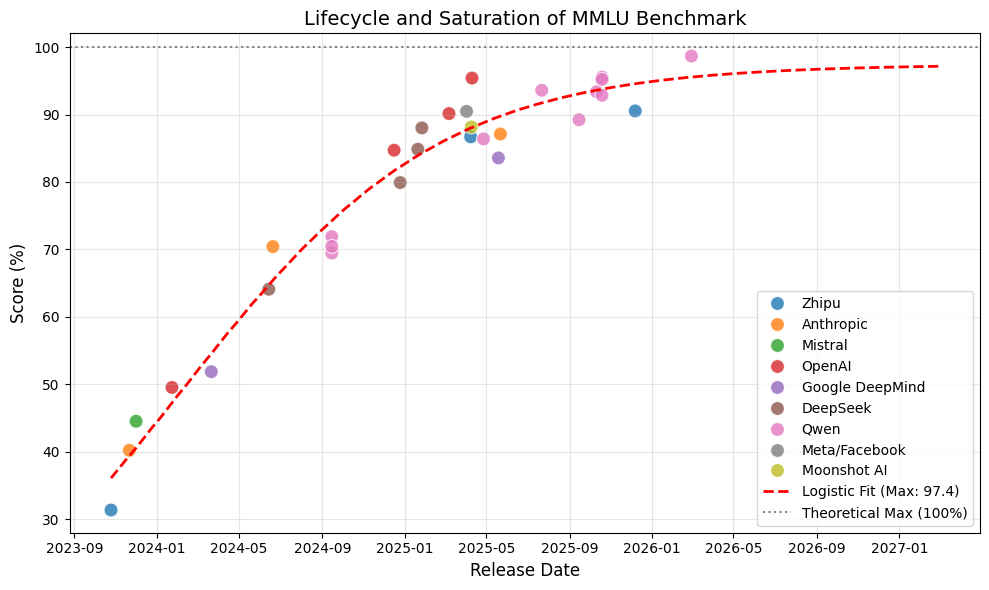

In [12]:
# Define the Logistic growth curve function
def logistic_func(x, L, k, x0):
    """
    L: Maximum value of the curve (saturation point)
    k: Growth rate
    x0: Midpoint (time of fastest growth)
    """
    return L / (1 + np.exp(-k * (x - x0)))

def plot_lifecycle_curve(df, target_benchmark):
    # Filter for the specific Benchmark
    b_df = df[df['benchmark_name'] == target_benchmark].copy()
    
    # Convert dates to 'months since first release' for easier numerical fitting
    min_date = b_df['release_date'].min()
    b_df['months_since_start'] = (b_df['release_date'] - min_date).dt.days / 30.44
    
    x_data = b_df['months_since_start'].values
    y_data = b_df['score'].values
    
    # Attempt to fit the Logistic curve
    try:
        # p0 represents initial guesses [L (max score 100), k (rate), x0 (midpoint)]
        popt, _ = curve_fit(logistic_func, x_data, y_data, p0=[100, 0.1, np.median(x_data)], maxfev=10000)
    except RuntimeError:
        print(f"Could not fit curve for {target_benchmark}.")
        return
        
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=b_df, x='release_date', y='score', hue='maker', s=100, alpha=0.8)
    
    # Generate a smooth X-axis for the curve (in months, predicting 12 months into the future)
    x_smooth = np.linspace(x_data.min(), x_data.max() + 12, 100) 
    y_smooth = logistic_func(x_smooth, *popt)
    
    # Convert numerical X back to datetime format for plotting
    dates_smooth = [min_date + pd.Timedelta(days=int(m * 30.44)) for m in x_smooth]
    
    plt.plot(dates_smooth, y_smooth, 'r--', linewidth=2, label=f'Logistic Fit (Max: {popt[0]:.1f})')
    
    plt.title(f'Lifecycle and Saturation of {target_benchmark} Benchmark', fontsize=14)
    plt.xlabel('Release Date', fontsize=12)
    plt.ylabel('Score (%)', fontsize=12)
    plt.axhline(y=100, color='gray', linestyle=':', label='Theoretical Max (100%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'lifecycle_{target_benchmark}.png', dpi=300)
    plt.show()

# Call the function to plot the lifecycle of MMLU
plot_lifecycle_curve(df, 'MMLU')

<Figure size 1000x800 with 0 Axes>

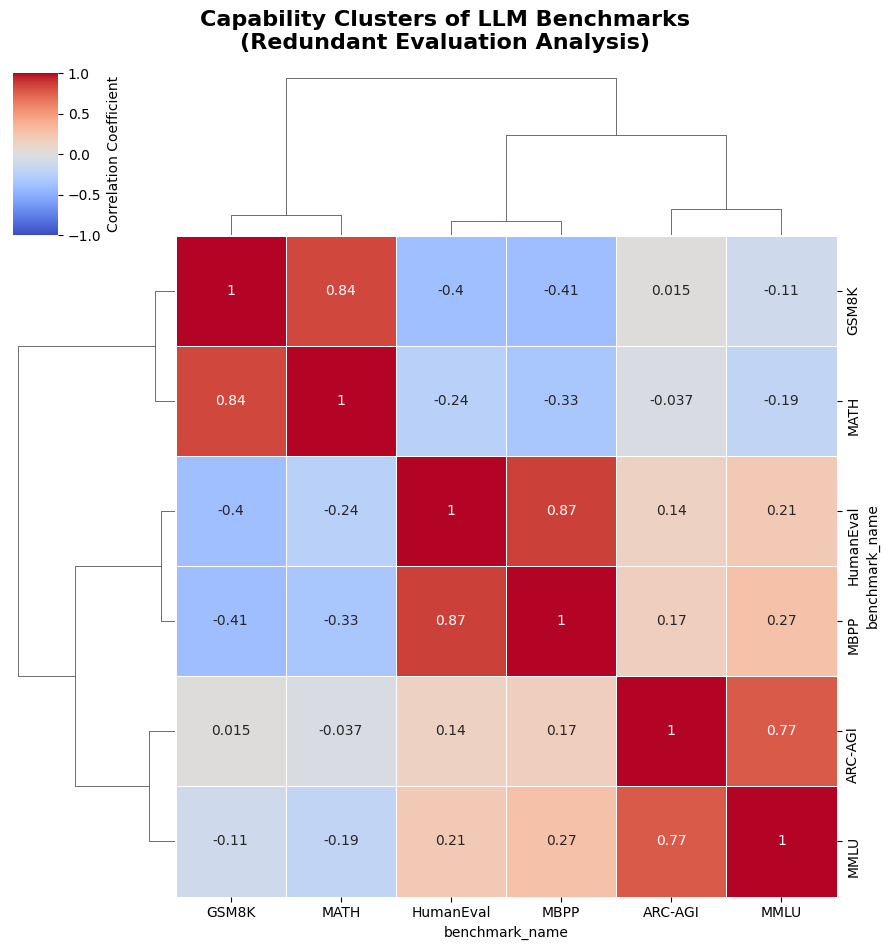

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Load and merge model metadata
# ==========================================
# Read the files from the same directory
df_csv = pd.read_csv('combined_models_030301.csv')
df_json = pd.read_json('combined_models_030301.json')

# Combine and remove duplicates
models_df = pd.concat([df_csv, df_json], ignore_index=True)
models_df = models_df.drop_duplicates(subset=['model_id'])

# ==========================================
# 2. Generate Realistic Mock Scores for Clustering
# 🚨 Replace this part when you receive real benchmark data!
# ==========================================
np.random.seed(42) # Set seed for reproducibility
sample_models = models_df['model_name'].dropna().unique()[:20] # Select 20 models

mock_data = []
for model in sample_models:
    # Simulate "Latent Abilities" for each model
    # Some models are good at math, some at coding, some at reasoning
    math_ability = np.random.normal(60, 15)
    coding_ability = np.random.normal(50, 20)
    reasoning_ability = np.random.normal(70, 10)
    
    # Generate benchmark scores based on these hidden abilities (adding some noise)
    scores = {
        'GSM8K': math_ability + np.random.normal(0, 5),          # Correlated with Math
        'MATH': math_ability * 0.8 + np.random.normal(0, 5),     # Correlated with Math
        'HumanEval': coding_ability + np.random.normal(0, 5),    # Correlated with Coding
        'MBPP': coding_ability * 0.9 + np.random.normal(0, 5),   # Correlated with Coding
        'MMLU': reasoning_ability + np.random.normal(0, 5),      # Correlated with Reasoning
        'ARC-AGI': reasoning_ability * 0.85 + np.random.normal(0, 5) # Correlated with Reasoning
    }
    
    for bench, score in scores.items():
        # Ensure scores are within 0 to 100
        score = np.clip(score, 0.1, 99.9) + np.random.uniform(0, 0.01)
        mock_data.append({'model_name': model, 'benchmark_name': bench, 'score': score})

scores_df = pd.DataFrame(mock_data)

# ==========================================
# 3. Structural Analysis: Model-by-Benchmark Matrix
# ==========================================
# Create a pivot table: Rows = Models, Columns = Benchmarks
pivot_df = scores_df.pivot_table(index='model_name', columns='benchmark_name', values='score')

# Calculate the Pearson correlation matrix between benchmarks
corr_matrix = pivot_df.corr()

# ==========================================
# 4. Plot the Clustered Heatmap
# ==========================================
plt.figure(figsize=(10, 8))

# Use seaborn's clustermap to automatically perform hierarchical clustering
g = sns.clustermap(
    corr_matrix, 
    annot=True,              # Show correlation numbers in the boxes
    cmap='coolwarm',         # Blue for negative, Red for positive correlation
    vmin=-1, vmax=1,         # Correlation ranges from -1 to 1
    linewidths=0.5,
    figsize=(9, 9),
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Set the title
g.fig.suptitle('Capability Clusters of LLM Benchmarks\n(Redundant Evaluation Analysis)', y=1.05, fontsize=16, fontweight='bold')

# Save and show the plot
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()